# Prepare Norman data, train PDAE model and show evals

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# NOTE: workaround for relative imports in Jupyter notebooks
# This is necessary because the notebook is run from a different directory
# and the relative imports in the modules will fail otherwise.
import sys
sys.path.append("../")
sys.path.append("../../")

In [3]:
import os
import random
from datetime import datetime
from pathlib import Path
import numpy as np
import torch
import anndata as ad
import pandas as pd
import seaborn as sns
from scipy import sparse
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt


from gdown import download as gdown_download

from PerturbationExtrapolation.pdae.api import PDAEData, PDAEConfig, PDAEModel

## Train from Scratch

In [4]:
SEED = 2
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

Download and store the data

In [5]:
# NOTE: this is the path where the Norman data is stored; customize this
storage_path = Path("../data")
norman_adata_path = storage_path / "Norman2019_processed.h5ad"

if not norman_adata_path.exists():
    url = "https://drive.google.com/uc?id=1FbA4UPBIuoWnWqfBhnX8LQy-FLS31pbH"
    gdown_download(url, str(norman_adata_path), quiet=False)

In [ ]:
# load the Norman adata
adata = ad.read_h5ad(norman_adata_path)

### Data exploration and visualization

In [10]:
adata.obs.head()

,cov_drug_dose_name,dose_val,control,condition,guide_identity,drug_dose_name,cell_type,split,split_poc,split1,...,split16,split17,split18,split19,split20,split21,split22,split23,split24,split25
index,,,,,,,,,,,,,,,,,,,,,
AAACCTGAGAAGAAGC-1,A549_ctrl_1,1,1,ctrl,NegCtrl0_NegCtrl0__NegCtrl0_NegCtrl0,ctrl_1,A549,train,train,train,...,train,train,train,train,train,train,train,train,train,train
AAACCTGAGGCATGTG-1,A549_TSC22D1+ctrl_1+1,1+1,0,TSC22D1+ctrl,TSC22D1_NegCtrl0__TSC22D1_NegCtrl0,TSC22D1+ctrl_1+1,A549,train,train,train,...,train,train,train,train,train,train,train,train,train,train
AAACCTGAGGCCCTTG-1,A549_KLF1+MAP2K6_1+1,1+1,0,KLF1+MAP2K6,KLF1_MAP2K6__KLF1_MAP2K6,KLF1+MAP2K6_1+1,A549,train,train,train,...,ood,ood,ood,ood,train,train,train,ood,train,train
AAACCTGCACGAAGCA-1,A549_ctrl_1,1,1,ctrl,NegCtrl10_NegCtrl0__NegCtrl10_NegCtrl0,ctrl_1,A549,train,train,test,...,train,train,train,train,train,train,train,train,test,test
AAACCTGCAGACGTAG-1,A549_CEBPE+RUNX1T1_1+1,1+1,0,CEBPE+RUNX1T1,CEBPE_RUNX1T1__CEBPE_RUNX1T1,CEBPE+RUNX1T1_1+1,A549,train,train,train,...,ood,train,train,train,train,train,train,ood,train,train


In [11]:
adata.var.head()

,gene_symbols,highly_variable,means,dispersions,dispersions_norm
index,,,,,
ENSG00000239945,RP11-34P13.8,True,0.000139,0.821591,1.999459
ENSG00000223764,RP11-54O7.3,True,0.009975,0.453863,0.777815
ENSG00000187634,SAMD11,True,0.028155,0.826190,2.014739
ENSG00000187583,PLEKHN1,True,0.000175,0.433592,0.710471
ENSG00000188290,HES4,True,0.301794,0.438797,0.728025


=== Norman et al. (2019) Data Overview ===
Number of genes: 5000
Number of cells: 108497
Number of experimental conditions: 284
Number of unique single-gene perturbations: 0
Number of unique double-gene perturbations: 283

=== Gene Expression Level Analysis ===
Summary statistics of mean log1p expression across all cells for different genes:
Min: 0.0000, Median: 0.0005, Mean: 0.1151
Max: 5.2124, Std: 0.4192
Number of genes with mean log1p expression >= 0.01: 1326 genes
Number of genes with mean log1p expression >= 0.05: 921 genes
Number of genes with mean log1p expression >= 0.1: 761 genes
Number of genes with mean log1p expression >= 0.2: 591 genes
Number of genes with mean log1p expression >= 0.5: 327 genes

=== Gene Expression Prevalence Analysis ===
Summary statistics for gene prevalence:
Min: 0.0%, Median: 0.1%, Mean: 8.6%
Max: 100.0%, Std: 21.4%
Genes expressed in ≥ 1% of cells: 1394 genes (27.9% of all genes)
Genes expressed in ≥ 5% of cells: 1005 genes (20.1% of all genes)
Gene

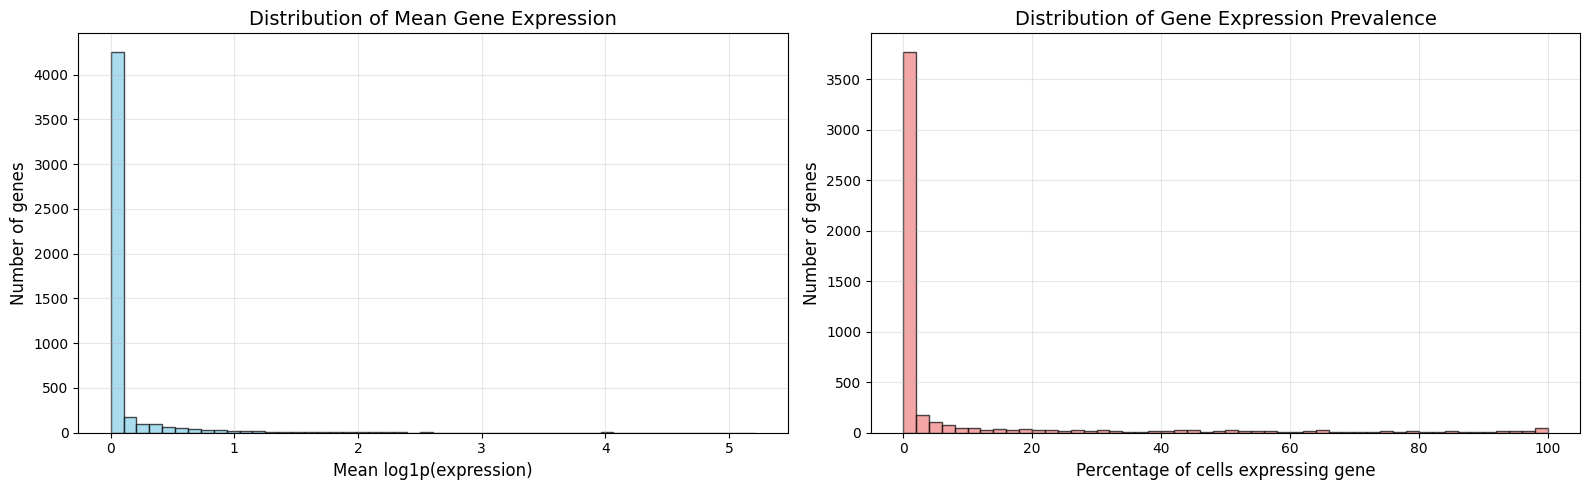

In [ ]:
print("=== Norman et al. (2019) Data Overview ===")
print(f"Number of genes: {len(adata.var_names)}")
print(f"Number of cells: {len(adata.obs_names)}")
print(f"Number of experimental conditions: {len(adata.obs['condition'].unique().tolist())}")

print("\n=== Gene Expression Level Analysis ===")

# Calculate mean expression across all cells for each gene directly from adata
if sparse.issparse(adata.X):
    overall_mean_expr = np.array(adata.X.mean(axis=0)).flatten()
    n_cells_expressing = np.array((adata.X > 0).sum(axis=0)).flatten()
else:
    overall_mean_expr = adata.X.mean(axis=0)
    n_cells_expressing = (adata.X > 0).sum(axis=0)

# Convert to pandas Series with gene names for easier indexing
overall_mean_expr = pd.Series(overall_mean_expr, index=adata.var_names)
gene_prevalence = pd.Series((n_cells_expressing / len(adata.obs_names)) * 100, index=adata.var_names)

# Print summary statistics for mean expression
print(f"Summary statistics of mean log1p expression across all cells for different genes:")
print(f"Min: {overall_mean_expr.min():.4f}, Median: {overall_mean_expr.median():.4f}, Mean: {overall_mean_expr.mean():.4f}")
print(f"Max: {overall_mean_expr.max():.4f}, Std: {overall_mean_expr.std():.4f}")

thresholds = [0.01, 0.05, 0.1, 0.2, 0.5]
for t in thresholds:
    n_genes = (overall_mean_expr >= t).sum()
    print(f"Number of genes with mean log1p expression >= {t}: {n_genes} genes")

print("\n=== Gene Expression Prevalence Analysis ===")
print(f"Summary statistics for gene prevalence:")
print(f"Min: {gene_prevalence.min():.1f}%, Median: {gene_prevalence.median():.1f}%, Mean: {gene_prevalence.mean():.1f}%")
print(f"Max: {gene_prevalence.max():.1f}%, Std: {gene_prevalence.std():.1f}%")

prevalence_thresholds = [1, 5, 10, 25, 50, 75]
for threshold in prevalence_thresholds:
    n_genes = (gene_prevalence >= threshold).sum()
    print(f"Genes expressed in ≥{threshold:2d}% of cells: {n_genes:4d} genes ({n_genes/len(adata.var_names)*100:.1f}% of all genes)")

# Show how many genes are never expressed
never_expressed = (gene_prevalence == 0).sum()
print(f"\nGenes never expressed in any cell: {never_expressed} genes ({never_expressed/len(adata.var_names)*100:.1f}% of all genes)")
print(f"\n=== Most and Least Prevalent Genes ===")
print("Top 10 most prevalent genes:")
for gene, prev in gene_prevalence.nlargest(10).items():
    print(f"  {gene}: {prev:.1f}% of cells")

print("\nTop 10 least prevalent genes (but expressed in >0% of cells):")
for gene, prev in gene_prevalence[gene_prevalence > 0].nsmallest(10).items():
    print(f"  {gene}: {prev:.1f}% of cells")

# Create combined plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Mean expression histogram
ax1.hist(overall_mean_expr, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_xlabel('Mean log1p(expression)', fontsize=12)
ax1.set_ylabel('Number of genes', fontsize=12)
ax1.set_title('Distribution of Mean Gene Expression', fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot 2: Gene prevalence histogram with threshold annotations
ax2.hist(gene_prevalence, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
ax2.set_xlabel('Percentage of cells expressing gene', fontsize=12)
ax2.set_ylabel('Number of genes', fontsize=12)
ax2.set_title('Distribution of Gene Expression Prevalence', fontsize=14)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Expression Value Distribution Analysis ===
Total entries in expression matrix: 542,485,000
Number of zero values: 495,792,543 (91.4%)
Number of non-zero values: 46,692,457

Statistics for all expression values (log1p transformed):
Min: 0.1944
Max: 8.8681
Mean: 1.3371
Median: 1.0389
Mode: 0.7418 (appears 3,999 times)
Std: 0.9465

Number of unique non-zero expression values: 1,561,615
Most frequent non-zero values:
  Value: 0.741793, Count: 3,999
  Value: 0.779991, Count: 3,908
  Value: 0.692713, Count: 3,882
  Value: 0.653248, Count: 3,862
  Value: 0.654435, Count: 3,817
  Value: 0.716960, Count: 3,796
  Value: 0.712139, Count: 3,786
  Value: 0.764876, Count: 3,761
  Value: 0.689152, Count: 3,696
  Value: 0.789850, Count: 3,676


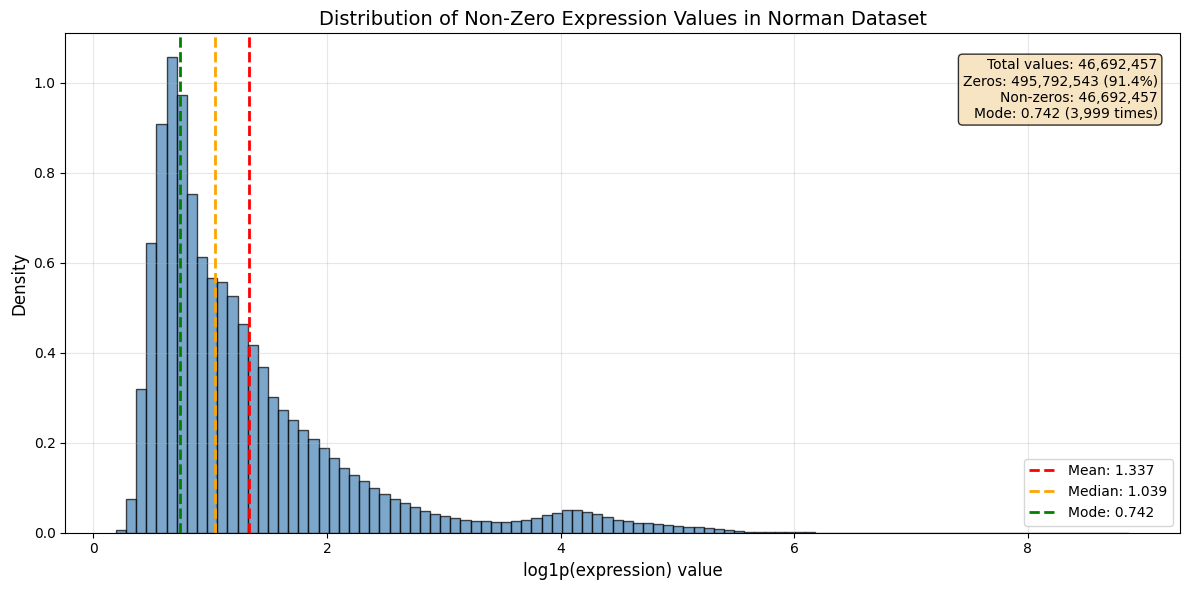

In [8]:
# Calculate and plot histogram of all expression values in the dataset
print("=== Expression Value Distribution Analysis ===")

# Get all expression values from the dataset
if sparse.issparse(adata.X):
    all_values = adata.X.data  # Only non-zero values for sparse matrix
    n_zeros = adata.X.shape[0] * adata.X.shape[1] - len(all_values)
else:
    all_values = adata.X.flatten()
    n_zeros = (all_values == 0).sum()

print(f"Total entries in expression matrix: {adata.X.shape[0] * adata.X.shape[1]:,}")
print(f"Number of zero values: {n_zeros:,} ({n_zeros/(adata.X.shape[0] * adata.X.shape[1])*100:.1f}%)")
print(f"Number of non-zero values: {len(all_values):,}")

# Calculate statistics for non-zero values
non_zero_values = all_values[all_values > 0] if not sparse.issparse(adata.X) else all_values

# Calculate mode (most frequent value)
unique_values, counts = np.unique(non_zero_values, return_counts=True)
mode_idx = np.argmax(counts)
mode_value = unique_values[mode_idx]

print(f"\nStatistics for all expression values (log1p transformed):")
print(f"Min: {non_zero_values.min():.4f}")
print(f"Max: {non_zero_values.max():.4f}")
print(f"Mean: {non_zero_values.mean():.4f}")
print(f"Median: {np.median(non_zero_values):.4f}")
print(f"Mode: {mode_value:.4f} (appears {counts[mode_idx]:,} times)")
print(f"Std: {non_zero_values.std():.4f}")
print(f"\nNumber of unique non-zero expression values: {len(unique_values):,}")
print(f"Most frequent non-zero values:")
# Get top 10 most frequent values
top_indices = np.argsort(counts)[-10:]
for i in reversed(top_indices):
    print(f"  Value: {unique_values[i]:.6f}, Count: {counts[i]:,}")

# Create histogram
plt.figure(figsize=(12, 6))

# Plot histogram of non-zero values
plt.hist(non_zero_values, bins=100, alpha=0.7, color='steelblue', edgecolor='black', density=True)
plt.xlabel('log1p(expression) value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution of Non-Zero Expression Values in Norman Dataset', fontsize=14)
plt.grid(True, alpha=0.3)

# Add vertical lines for key statistics
plt.axvline(non_zero_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {non_zero_values.mean():.3f}')
plt.axvline(np.median(non_zero_values), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(non_zero_values):.3f}')
plt.axvline(mode_value, color='green', linestyle='--', linewidth=2, label=f'Mode: {mode_value:.3f}')

# Add text box with statistics
stats_text = f'Total values: {len(all_values):,}\nZeros: {n_zeros:,} ({n_zeros/(adata.X.shape[0] * adata.X.shape[1])*100:.1f}%)\nNon-zeros: {len(non_zero_values):,}\nMode: {mode_value:.3f} ({counts[mode_idx]:,} times)'
plt.text(0.98, 0.95, stats_text, transform=plt.gca().transAxes, 
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()

=== Cell-wise Expression Sum Analysis ===
Statistics for sum of log1p expression per cell:
Min: 310.09
Max: 927.30
Mean: 575.42
Median: 573.98
Std: 45.53


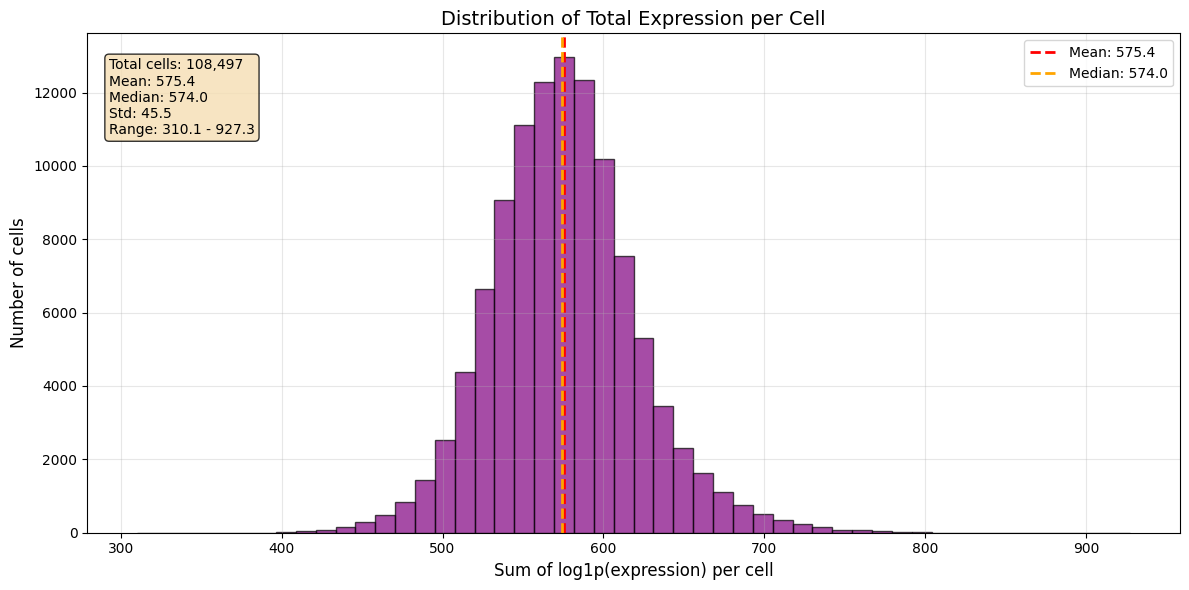


=== Expression Sum by Condition ===
Summary statistics by condition:
                count        mean      median        std
condition                                               
AHR+FEV           276  627.299988  623.950012  54.090000
AHR+KLF1          481  593.780029  595.880005  38.189999
AHR+ctrl          558  589.070007  587.000000  43.680000
ARID1A+ctrl       232  561.570007  559.669983  46.540001
ARRDC3+ctrl       495  564.479980  565.280029  38.860001
ATL1+ctrl         379  556.950012  557.859985  43.660000
BAK1+ctrl         687  570.270020  572.030029  37.720001
BCL2L11+BAK1      175  566.159973  568.549988  37.279999
BCL2L11+ctrl      582  567.289978  567.780029  38.540001
BCL2L11+TGFBR2    463  563.929993  567.340027  37.490002


/tmp/ipykernel_1034960/1240291710.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  condition_stats = condition_sums.groupby('condition')['cell_sum'].agg(['count', 'mean', 'median', 'std']).round(2)
/tmp/ipykernel_1034960/1240291710.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=condition_subset, x='condition', y='cell_sum', palette='Set2')


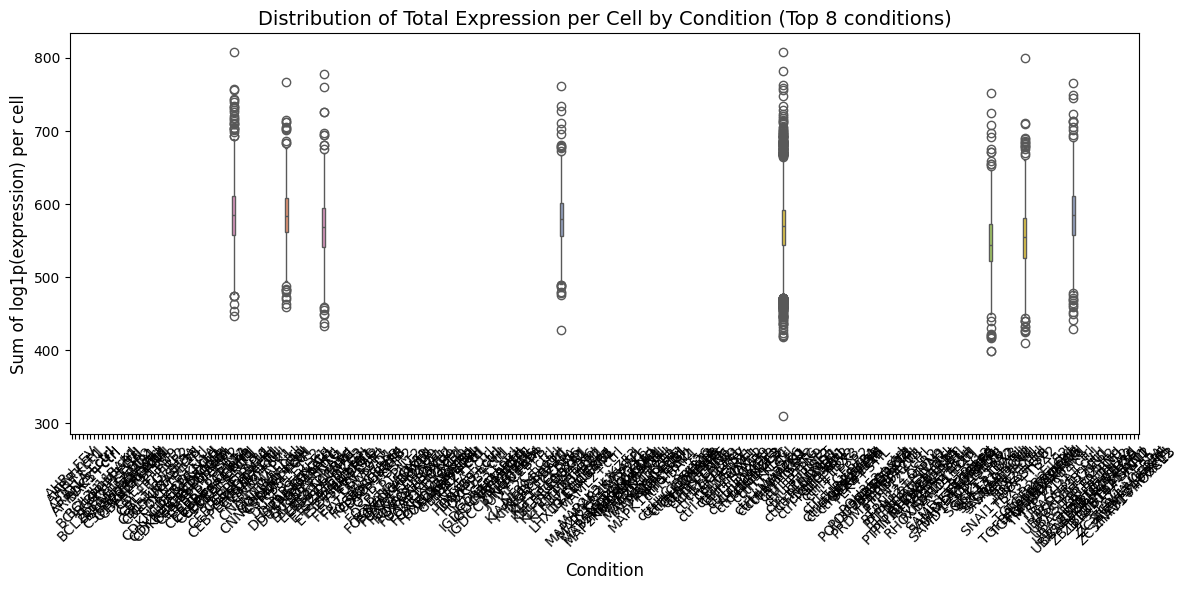

In [11]:
# Calculate sum of expression levels per cell and plot distribution
print("=== Cell-wise Expression Sum Analysis ===")

# Calculate sum of expression for each cell (across all genes)
if sparse.issparse(adata.X):
    cell_expr_sums = np.array(adata.X.sum(axis=1)).flatten()
else:
    cell_expr_sums = adata.X.sum(axis=1)

print(f"Statistics for sum of log1p expression per cell:")
print(f"Min: {cell_expr_sums.min():.2f}")
print(f"Max: {cell_expr_sums.max():.2f}")
print(f"Mean: {cell_expr_sums.mean():.2f}")
print(f"Median: {np.median(cell_expr_sums):.2f}")
print(f"Std: {cell_expr_sums.std():.2f}")

# Plot distribution of cell expression sums
plt.figure(figsize=(12, 6))

plt.hist(cell_expr_sums, bins=50, alpha=0.7, color='purple', edgecolor='black', density=False)
plt.xlabel('Sum of log1p(expression) per cell', fontsize=12)
plt.ylabel('Number of cells', fontsize=12)
plt.title('Distribution of Total Expression per Cell', fontsize=14)
plt.grid(True, alpha=0.3)

# Add vertical lines for key statistics
plt.axvline(cell_expr_sums.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cell_expr_sums.mean():.1f}')
plt.axvline(np.median(cell_expr_sums), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(cell_expr_sums):.1f}')

# Add text box with statistics
stats_text = f'Total cells: {len(cell_expr_sums):,}\nMean: {cell_expr_sums.mean():.1f}\nMedian: {np.median(cell_expr_sums):.1f}\nStd: {cell_expr_sums.std():.1f}\nRange: {cell_expr_sums.min():.1f} - {cell_expr_sums.max():.1f}'
plt.text(0.02, 0.95, stats_text, transform=plt.gca().transAxes, 
         verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()

# Additional analysis: Check if expression sum varies by condition
print(f"\n=== Expression Sum by Condition ===")
condition_sums = pd.DataFrame({
    'cell_sum': cell_expr_sums,
    'condition': adata.obs['condition'].values
})

condition_stats = condition_sums.groupby('condition')['cell_sum'].agg(['count', 'mean', 'median', 'std']).round(2)
print("Summary statistics by condition:")
print(condition_stats.head(10))  # Show first 10 conditions

# Plot boxplot by condition for top conditions
top_conditions = adata.obs['condition'].value_counts().head(8).index.tolist()
condition_subset = condition_sums[condition_sums['condition'].isin(top_conditions)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=condition_subset, x='condition', y='cell_sum', palette='Set2')
plt.xticks(rotation=45)
plt.xlabel('Condition', fontsize=12)
plt.ylabel('Sum of log1p(expression) per cell', fontsize=12)
plt.title('Distribution of Total Expression per Cell by Condition (Top 8 conditions)', fontsize=14)
plt.tight_layout()
plt.show()

Total genes: 5000
Genes with mean expression > 0.05: 921
Genes passing non-zero ratio filter > 0.05: 921
Selected perturbations: ['ctrl', 'TSC22D1+ctrl', 'KLF1+MAP2K6', 'CEBPE+RUNX1T1', 'MAML2+ctrl', 'ctrl+CEBPE', 'ETS2+MAP7D1', 'CBL+PTPN9', 'LHX1+ELMSAN1', 'TGFBR2+ETS2', 'SGK1+TBX3', 'DUSP9+ctrl', 'MAP2K6+SPI1', 'ctrl+ELMSAN1', 'UBASH3B+ctrl', 'UBASH3B+PTPN12', 'ctrl+FOXA1', 'FOXA3+FOXA1', 'ETS2+IGDCC3', 'BCORL1+ctrl']
Number genes with absolute fold change > 0.25 in expression for the selected perturbations: 874
Selected 20 genes with good expression levels: ['ENSG00000151725', 'ENSG00000119979', 'ENSG00000137203', 'ENSG00000149564', 'ENSG00000106052', 'ENSG00000182481', 'ENSG00000185338', 'ENSG00000000971', 'ENSG00000117450', 'ENSG00000114784', 'ENSG00000196924', 'ENSG00000100906', 'ENSG00000119655', 'ENSG00000163870', 'ENSG00000011600', 'ENSG00000151287', 'ENSG00000197465', 'ENSG00000245532', 'ENSG00000213722', 'ENSG00000196776']


NameError: name 'pdae_save_dir' is not defined

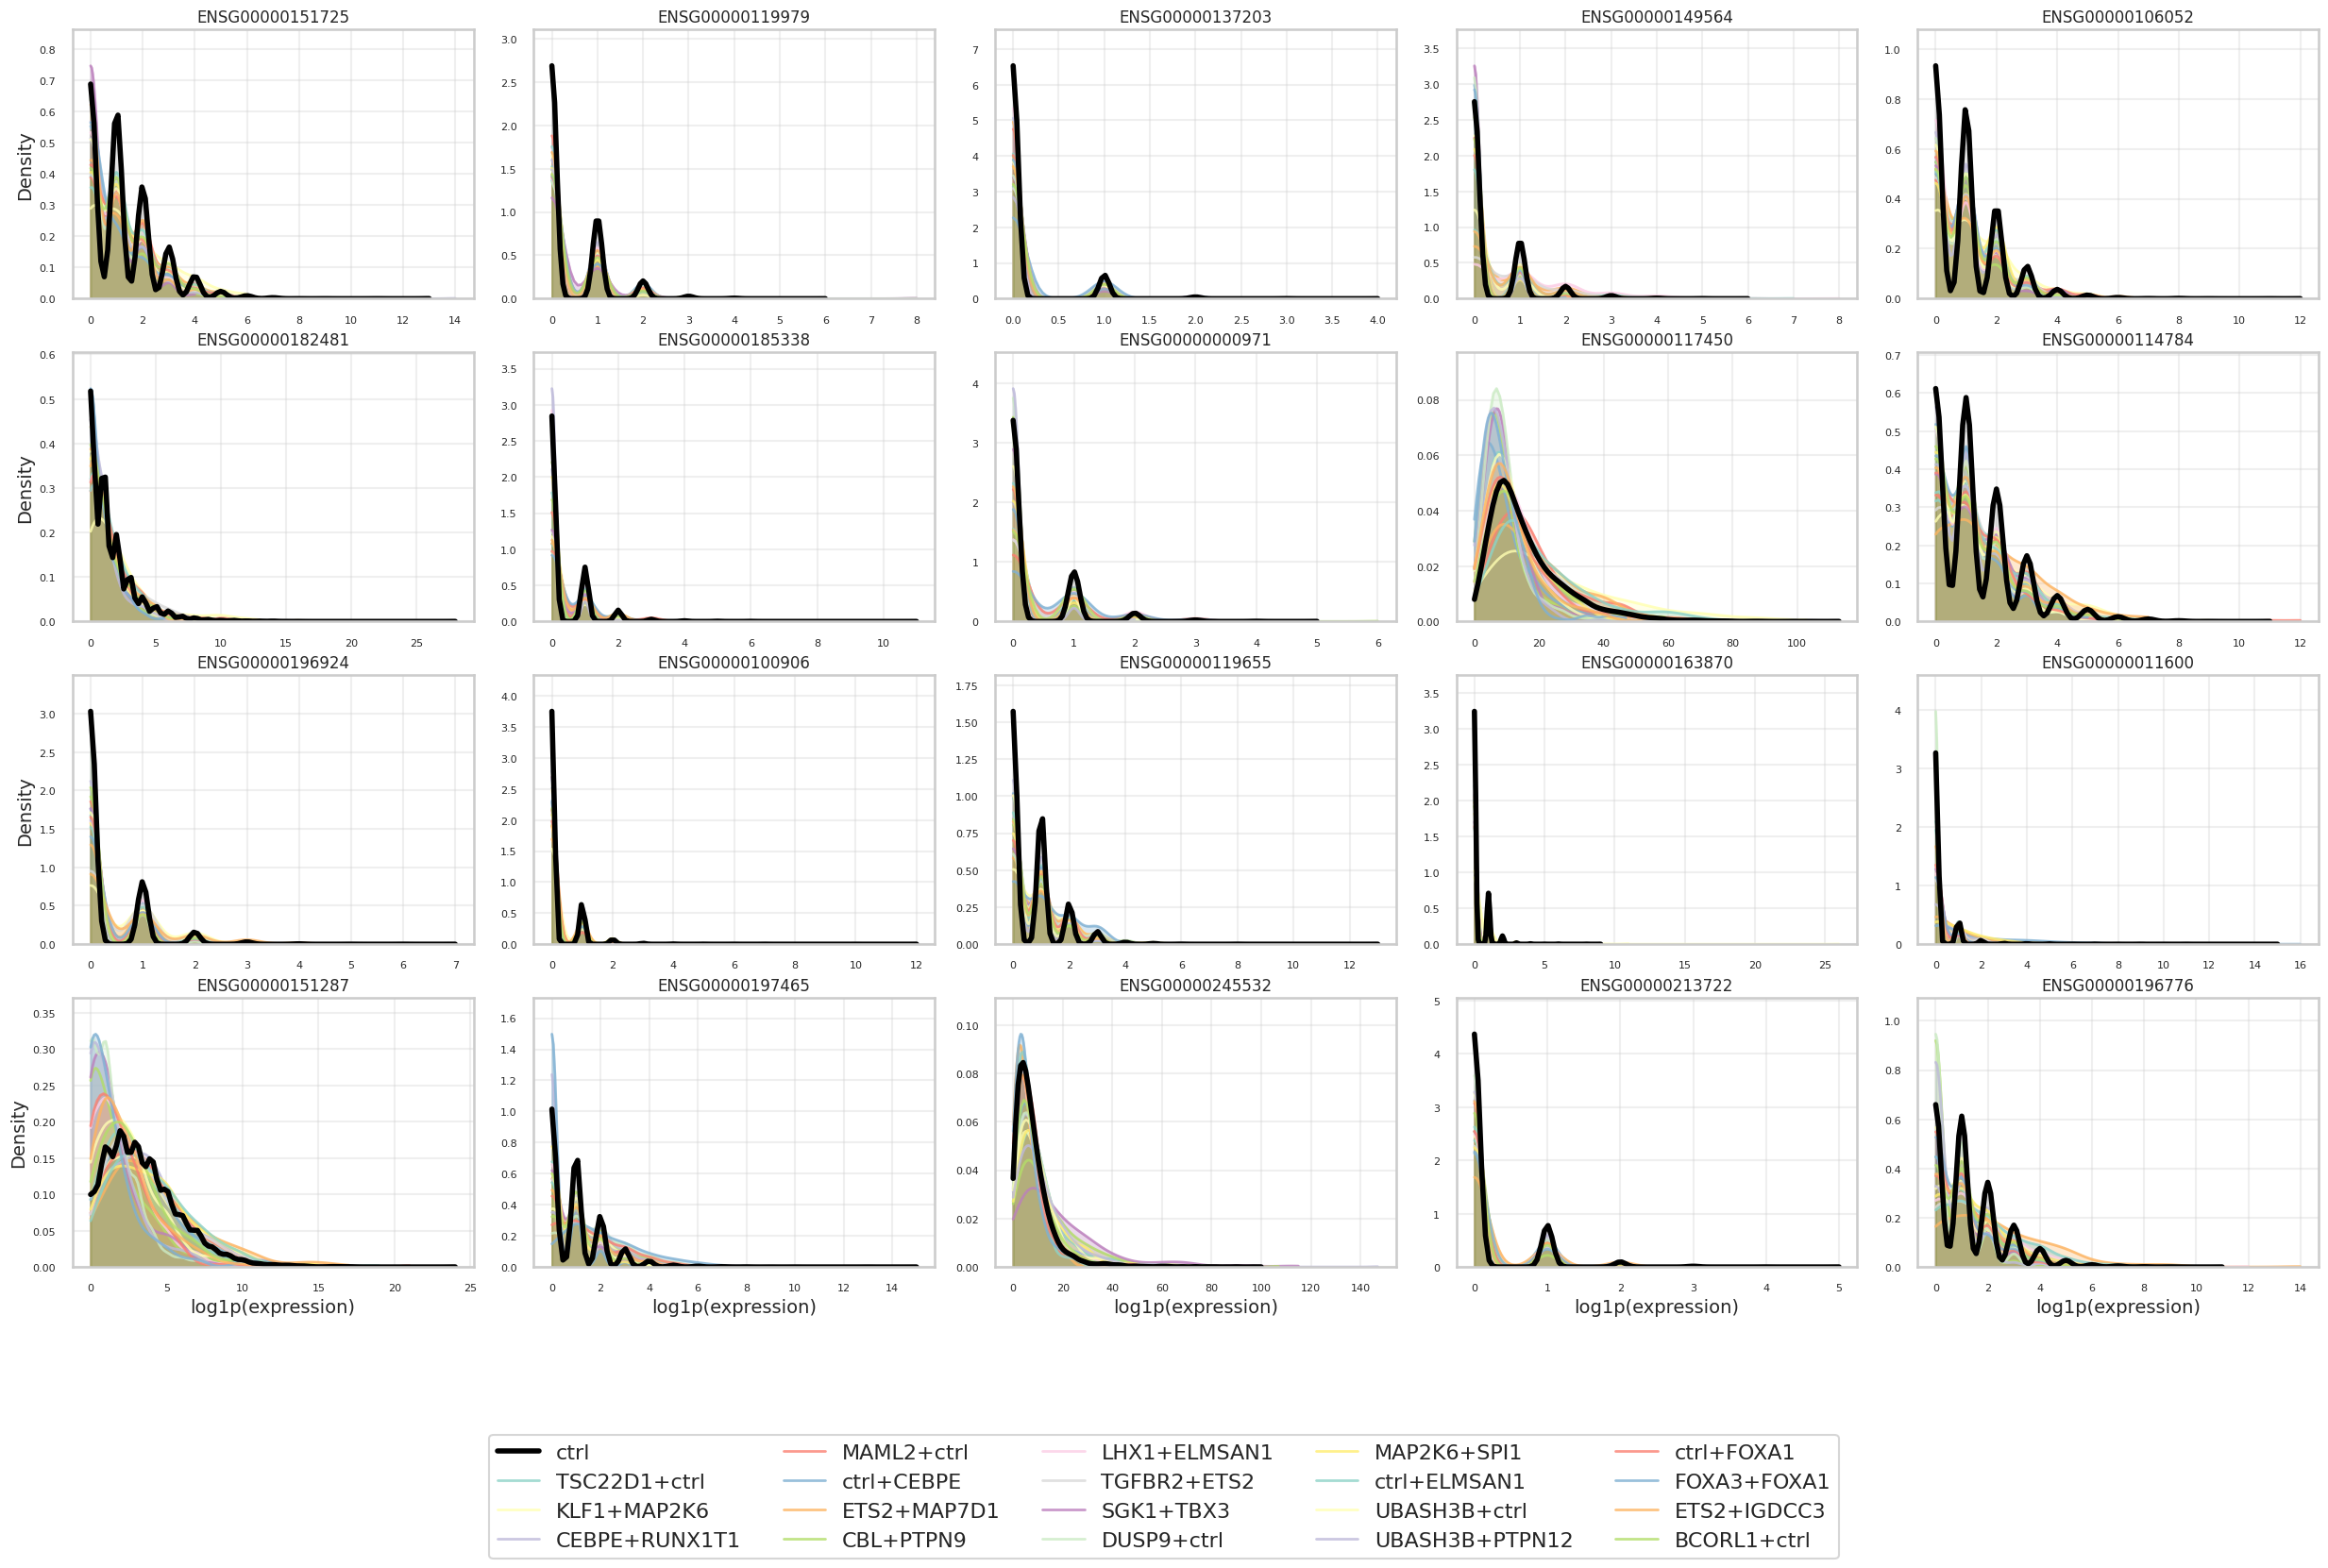

In [15]:
# Visualize expression distributions for a few genes across control and selected perturbations
# Parameters for gene filtering
MIN_MEAN_EXPR = 0.05          # Minimum mean expression across all cells
MIN_NON_ZERO_RATIO = 0.05    # Minimum fraction of cells that must express the gene
MIN_FOLD_CHANGE = 0.25        # Minimum fold change for differential expression
N_PERTURBATIONS = 20         # Number of perturbations to consider (including control)

# Filter out genes with very low expression across all conditions

# Build expr_df aligned to adata.obs and adata.var_names.
# If raw counts are stored in adata.layers['counts'] use that; otherwise fall back to adata.X.
counts = adata.layers['counts'] if 'counts' in adata.layers.keys() else adata.X

# Convert sparse/dense objects safely to a numpy array without requiring a scipy import here.
if hasattr(counts, "toarray"):
    counts_arr = counts.toarray()
elif hasattr(counts, "A"):
    counts_arr = counts.A
else:
    counts_arr = np.array(counts)


expr_matrix = counts_arr

expr_df = pd.DataFrame(expr_matrix, index=adata.obs_names, columns=adata.var_names)

# Only consider genes with mean expression > MIN_MEAN_EXPR
expressed_genes = overall_mean_expr[overall_mean_expr > MIN_MEAN_EXPR].index.tolist()

print(f"Total genes: {len(adata.var_names)}")
print(f"Genes with mean expression > {MIN_MEAN_EXPR}: {len(expressed_genes)}")

# Apply non-zero ratio filter to all genes upfront
filtered_genes = []
for gene in expressed_genes:
    gene_expr = expr_df[gene]
    non_zero_ratio = (gene_expr > 0).mean()
    if non_zero_ratio > MIN_NON_ZERO_RATIO:
        filtered_genes.append(gene)

print(f"Genes passing non-zero ratio filter > {MIN_NON_ZERO_RATIO}: {len(filtered_genes)}")

# check condition/perturbation column
pert_col = "condition"
if pert_col not in adata.obs.columns:
    raise KeyError(f"Expected obs column '{pert_col}' not found in adata.obs")

# pick control and other perturbations
unique_perts = list(adata.obs[pert_col].unique())
if "ctrl" in unique_perts:
    others = [p for p in unique_perts if p != "ctrl"]
    chosen_perts = ["ctrl"] + others[:N_PERTURBATIONS-1]
else:
    chosen_perts = unique_perts[:N_PERTURBATIONS]

print(f"Selected perturbations: {chosen_perts}")

# Calculate differential expression (fold change relative to control)
ctrl_mask = adata.obs[pert_col] == "ctrl"
ctrl_mean = expr_df[ctrl_mask].mean()

diff_scores = []
for gene in filtered_genes:  # Only consider genes that passed all filters
    max_fold_change = 0
    for pert in chosen_perts[1:]:  # Skip control
        pert_mask = adata.obs[pert_col] == pert
        if pert_mask.sum() > 0:
            pert_mean = expr_df.loc[pert_mask, gene].mean()
            ctrl_gene_mean = ctrl_mean[gene]
            if ctrl_gene_mean > 0:
                fold_change = abs(pert_mean / ctrl_gene_mean - 1)
                max_fold_change = max(max_fold_change, fold_change)
    diff_scores.append((gene, max_fold_change))

# Sort by differential expression and filter out genes with no change
diff_scores.sort(key=lambda x: x[1], reverse=True)

# Filter to only genes with significant differential expression (fold change > MIN_FOLD_CHANGE)
diff_genes = []
for gene, score in diff_scores:
    if score > MIN_FOLD_CHANGE or score < -MIN_FOLD_CHANGE:
        diff_genes.append(gene)

print(f"Number genes with absolute fold change > {MIN_FOLD_CHANGE} in expression for the selected perturbations: {len(diff_genes)}")

# Randomly sample 20 genes from the differentially expressed genes
np.random.seed(SEED)  # Use the same seed for reproducibility
if len(diff_genes) >= 20:
    sel_genes = np.random.choice(diff_genes, 20, replace=False).tolist()
else:
    # If fewer than 20 DE genes, take all DE genes plus fill with top expressed genes
    remaining_needed = 20 - len(diff_genes)
    # Get top expressed genes that aren't already selected (from filtered_genes)
    top_expressed_filtered = overall_mean_expr.loc[filtered_genes].sort_values(ascending=False)
    additional_genes = []
    for gene in top_expressed_filtered.index:
        if gene not in diff_genes and len(additional_genes) < remaining_needed:
            additional_genes.append(gene)
    
    sel_genes = diff_genes + additional_genes

print(f"Selected 20 genes with good expression levels: {sel_genes}")

# build a long-form DataFrame with log1p-transformed expression for selected genes
expr_long = (
    expr_df[sel_genes]
    .loc[adata.obs.index]  # ensure alignment
    .assign(condition=adata.obs[pert_col].values)
    .reset_index()
    .melt(id_vars=["index", "condition"], value_vars=sel_genes, var_name="gene", value_name="expr_log1p")
)

# filter to chosen perturbations
expr_long = expr_long[expr_long["condition"].isin(chosen_perts)]

# plot in 4x5 layout using kernel density plots
sns.set(style="whitegrid", context="talk")
n_genes = len(sel_genes)
fig, axes = plt.subplots(4, 5, figsize=(25, 16))  # Reduced height from 20 to 16
axes = axes.flatten()

# Define colors for each perturbation (excluding control)
non_ctrl_perts = [p for p in chosen_perts if p != "ctrl"]
colors = sns.color_palette("Set3", len(non_ctrl_perts))
color_map = dict(zip(non_ctrl_perts, colors))
# Control is always black and thick
color_map["ctrl"] = "black"

# Store legend handles for the shared legend
legend_handles = []

for i, gene in enumerate(sel_genes):
    ax = axes[i]
    sub = expr_long[expr_long["gene"] == gene]
    
    # Plot kernel density for each condition
    # First plot all perturbations (non-control conditions)
    for condition in [p for p in chosen_perts if p != "ctrl"]:
        condition_data = sub[sub["condition"] == condition]["expr_log1p"]
        
        # Set style for perturbations
        linewidth = 2  # Normal thickness for perturbations
        alpha = 0.8    # Slight transparency for perturbations
        fill_alpha = 0.3  # Normal fill for perturbations
        
        if len(condition_data) > 1:  # Need at least 2 points for KDE
            # Check if data has variance (not all identical values)
            if condition_data.std() > 1e-10:
                try:
                    kde = gaussian_kde(condition_data)
                    x_range = np.linspace(condition_data.min(), condition_data.max(), 100)
                    density = kde(x_range)
                    line, = ax.plot(x_range, density, color=color_map[condition], 
                           label=condition, linewidth=linewidth, alpha=alpha)
                    ax.fill_between(x_range, density, alpha=fill_alpha, color=color_map[condition])
                    # Collect legend handles from first subplot
                    if i == 0:
                        legend_handles.append(line)
                except np.linalg.LinAlgError:
                    # Fallback: plot a vertical line at the constant value
                    mean_val = condition_data.mean()
                    line = ax.axvline(mean_val, color=color_map[condition], 
                              label=condition, linewidth=linewidth, alpha=alpha)
                    if i == 0:
                        legend_handles.append(line)
            else:
                # All values are identical, plot a vertical line
                mean_val = condition_data.mean()
                line = ax.axvline(mean_val, color=color_map[condition], 
                          label=condition, linewidth=linewidth, alpha=alpha)
                if i == 0:
                    legend_handles.append(line)
        elif len(condition_data) == 1:
            # Single data point, plot as vertical line
            line = ax.axvline(condition_data.iloc[0], color=color_map[condition], 
                      label=condition, linewidth=linewidth, alpha=alpha)
            if i == 0:
                legend_handles.append(line)
    
    # Plot control last so it appears on top
    if "ctrl" in chosen_perts:
        condition = "ctrl"
        condition_data = sub[sub["condition"] == condition]["expr_log1p"]
        
        # Set style for control
        linewidth = 4  # Thick for control
        alpha = 1.0    # Full opacity for control
        fill_alpha = 0.1  # Light fill for control
        
        if len(condition_data) > 1:  # Need at least 2 points for KDE
            # Check if data has variance (not all identical values)
            if condition_data.std() > 1e-10:
                try:
                    kde = gaussian_kde(condition_data)
                    x_range = np.linspace(condition_data.min(), condition_data.max(), 100)
                    density = kde(x_range)
                    line, = ax.plot(x_range, density, color=color_map[condition], 
                           label=condition, linewidth=linewidth, alpha=alpha)
                    ax.fill_between(x_range, density, alpha=fill_alpha, color=color_map[condition])
                    # Collect legend handles from first subplot (add control first for legend order)
                    if i == 0:
                        legend_handles.insert(0, line)  # Insert at beginning for legend ordering
                except np.linalg.LinAlgError:
                    # Fallback: plot a vertical line at the constant value
                    mean_val = condition_data.mean()
                    line = ax.axvline(mean_val, color=color_map[condition], 
                              label=condition, linewidth=linewidth, alpha=alpha)
                    if i == 0:
                        legend_handles.insert(0, line)
            else:
                # All values are identical, plot a vertical line
                mean_val = condition_data.mean()
                line = ax.axvline(mean_val, color=color_map[condition], 
                          label=condition, linewidth=linewidth, alpha=alpha)
                if i == 0:
                    legend_handles.insert(0, line)
        elif len(condition_data) == 1:
            # Single data point, plot as vertical line
            line = ax.axvline(condition_data.iloc[0], color=color_map[condition], 
                      label=condition, linewidth=linewidth, alpha=alpha)
            if i == 0:
                legend_handles.insert(0, line)
    
    ax.set_title(gene, fontsize=12)  # Smaller title font
    
    # Only add x-label for bottom row (indices 15-19 for 4x5 grid)
    if i >= 15:
        ax.set_xlabel("log1p(expression)", fontsize=14)
    
    ax.set_ylabel("Density" if i % 5 == 0 else "", fontsize=14)  # Only show y-label for leftmost plots
    ax.grid(True, alpha=0.3)
    
    # Make y-axis more compact by reducing tick spacing and limits
    ax.tick_params(axis='both', which='major', labelsize=8)
    # Automatically adjust y-axis limits to make plots more compact
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax * 1.1)  # Start at 0 and add small margin at top

# Create legend labels in correct order (control first, then perturbations)
legend_labels = ["ctrl"] + [p for p in chosen_perts if p != "ctrl"]

# Add shared legend below the plot with larger font
fig.legend(legend_handles, legend_labels, loc='lower center', 
          bbox_to_anchor=(0.5, -0.05), ncol=5, fontsize=16)  # Increased font size

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, hspace=0.20, wspace=0.15)  # More compact spacing

# save figure to the experiment save directory (pdae_save_dir is defined earlier)
out_path = pdae_save_dir / "gene_distributions_kde.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to: {out_path}")

plt.show()